# Control Variates

In this notebook, I implement the control variates method for option pricing.
The content of this notebook is based on Chapter 4 of the book "Monte Carlo Methods in Financial Engineering" by Paul Glasserman.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Parameters

In [2]:
num_total_samples = 1000
terminal_time = 1

initial_stock_price = 100
riskless = 0.03
strike_price = 100

# "sigma" is a volatility term of GBM
sigma = 0.2

# "alpha" is a significance level for the confidence interval.
alpha = 0.05

# 2. Sampling from normal distribution

In [3]:
W = np.random.normal(loc=0, scale=np.sqrt(terminal_time), size = num_total_samples)

# 3. Simulation of the stock price

The model for stock price is 1-dimensional GBM;
$$ \frac{dS(t)}{S(t)} = r dt + \sigma dW(t).$$
To draw its path, we use the explicit form of GBM;
$$ S(t) = S(0) \exp \left \{(r - \frac{1}{2} \sigma^2) \ t + \sigma W(t) \right \}.$$

In [4]:
stock_price = initial_stock_price * np.exp((riskless - 1/2 * (sigma) * (sigma)) * terminal_time + sigma * W)

# 4. Computation of the call option prices

The value of the call option we consider is
$$e^{-rT}\mathbb{E}[(S(T) - K)^+],$$
where r is the risk-free rate, T is the terminal time and K is the strike price.

In [5]:
call_value = np.zeros(num_total_samples)
for i in range(num_total_samples):
    call_value[i] = np.exp(- riskless * terminal_time) * max(0, stock_price[i] - strike_price)

# 5. Estimator with control variate

In [6]:
call_value_mean = np.mean(call_value)
stock_price_mean = np.mean(stock_price)

b = np.dot(stock_price - stock_price_mean, call_value - call_value_mean)/(np.dot(stock_price - stock_price_mean, stock_price - stock_price_mean))

Y_b = call_value - b * (stock_price - np.exp(riskless * terminal_time) * initial_stock_price)
estimated_price = np.mean(Y_b)
std = np.std(Y_b, ddof=1)

z = norm.ppf(1 - alpha/2)
conf_int_lower = estimated_price - z * std/np.sqrt(num_total_samples)
conf_int_upper = estimated_price + z * std/np.sqrt(num_total_samples)
print(f"The estimated value is {estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower:.3f},{conf_int_upper:.3f}). \n\
The length of this interval  is {conf_int_upper - conf_int_lower:.4f}")

The estimated value is 9.506, and 
95.0% confidence interval is (9.145,9.867). 
The length of this interval  is 0.7224


# 6. Calculation of sample correlation

In [7]:
sample_corr = np.dot(stock_price - stock_price_mean, call_value - call_value_mean)/ \
    (np.sqrt(np.dot(stock_price - stock_price_mean,stock_price - stock_price_mean)) \
     * np.sqrt(np.dot(call_value - call_value_mean,call_value - call_value_mean)))

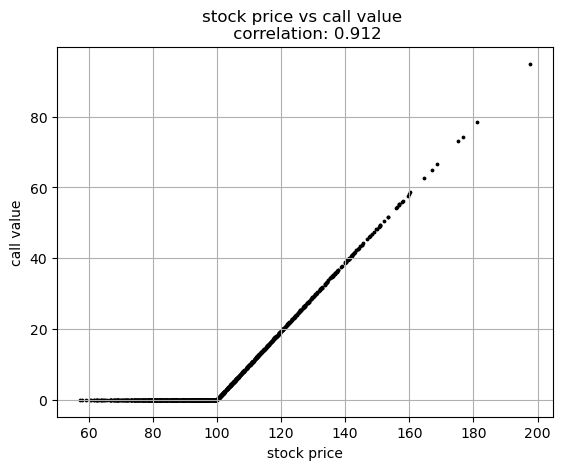

In [8]:
plt.scatter(stock_price, call_value, s=3, color = "black")
plt.title(f"stock price vs call value \n correlation: {sample_corr:.3f}")
plt.xlabel("stock price")
plt.ylabel("call value")
plt.grid(True)

# 6. Comparison with plain MC

In [9]:
plain_estimated_price = call_value_mean
plain_std = np.std(call_value, ddof=1)

plain_conf_int_lower = plain_estimated_price - z * plain_std/np.sqrt(num_total_samples)
plain_conf_int_upper = plain_estimated_price + z * plain_std/np.sqrt(num_total_samples)
print(f"The estimated value is {plain_estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({plain_conf_int_lower:.3f},{plain_conf_int_upper:.3f}). \n\
The length of this interval  is {plain_conf_int_upper - plain_conf_int_lower:.4f}")

The estimated value is 9.327, and 
95.0% confidence interval is (8.446,10.207). 
The length of this interval  is 1.7614
